In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nasa-cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/x.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CM

In [2]:
data = pd.read_csv("../input/nasa-cmaps/CMaps/train_FD001.txt", sep=" ", header=None)

In [3]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [4]:
COLS = ["ID", "Cycle", "OpSet1", "OpSet2", "OpSet3", "SensorMeasure1", "SensorMeasure2", "SensorMeasure3", "SensorMeasure4",
                "SensorMeasure5", "SensorMeasure6", "SensorMeasure7", "SensorMeasure8", "SensorMeasure9", "SensorMeasure10", "SensorMeasure11",
                "SensorMeasure12", "SensorMeasure13", "SensorMeasure14", "SensorMeasure15", "SensorMeasure16",
                "SensorMeasure17", "SensorMeasure18", "SensorMeasure19", "SensorMeasure20", "SensorMeasure21"]

In [5]:
# NaN olan sütunları çıkarıp başlıkları ekle
data = data[[f for f in range(0, 26)]]
data.columns = ["ID", "Cycle", "OpSet1", "OpSet2", "OpSet3", "SensorMeasure1", "SensorMeasure2", "SensorMeasure3", "SensorMeasure4",
                "SensorMeasure5", "SensorMeasure6", "SensorMeasure7", "SensorMeasure8", "SensorMeasure9", "SensorMeasure10", "SensorMeasure11",
                "SensorMeasure12", "SensorMeasure13", "SensorMeasure14", "SensorMeasure15", "SensorMeasure16",
                "SensorMeasure17", "SensorMeasure18", "SensorMeasure19", "SensorMeasure20", "SensorMeasure21"]

In [6]:
data

,ID,Cycle,OpSet1,OpSet2,OpSet3,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,...,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [7]:
# Sadece 1 ID'li engine'in bilgileri
data[data["ID"]==1]

,ID,Cycle,OpSet1,OpSet2,OpSet3,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,...,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295


In [8]:
# Her engine'in kaç cycle dayandığının bilgisi
max_cycles_df = data.groupby(["ID"], sort=False)["Cycle"].max().reset_index().rename(columns={"Cycle" : "MaxCycleID"})
max_cycles_df.head()

,ID,MaxCycleID
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [9]:
# Remaining Useful Life (RUL) ile dataseti birleştir
FD001_df = pd.merge(data, max_cycles_df, how="inner", on="ID")
FD001_df["RUL"] = FD001_df["MaxCycleID"] - FD001_df["Cycle"]
FD001_df

,ID,Cycle,OpSet1,OpSet2,OpSet3,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,...,SensorMeasure14,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21,MaxCycleID,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,200,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,200,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,200,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,200,1


In [10]:
# CSV'ye dönüştür
FD001_df.to_csv("FD001.csv", index=None)

# VERİ NORMALİZASYONU VE GÖRSELLEŞTİRME

In [11]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [12]:
df_mini = FD001_df.copy().drop(columns=["ID", "Cycle", "OpSet1", "OpSet2", "OpSet3", "MaxCycleID", "RUL"], axis=1)
scaler = MinMaxScaler(feature_range=(0, 1))
print(df_mini)
scaled_df = pd.DataFrame(scaler.fit_transform(df_mini.values))
scaled_df = FD001_df[["ID", "Cycle", "RUL"]].join(scaled_df)
scaled_df.columns = ["ID", "Cycle","RUL", "SensorMeasure1", "SensorMeasure2", "SensorMeasure3", "SensorMeasure4",
                "SensorMeasure5", "SensorMeasure6", "SensorMeasure7", "SensorMeasure8", "SensorMeasure9", "SensorMeasure10", "SensorMeasure11",
                "SensorMeasure12", "SensorMeasure13", "SensorMeasure14", "SensorMeasure15", "SensorMeasure16",
                "SensorMeasure17", "SensorMeasure18", "SensorMeasure19", "SensorMeasure20", "SensorMeasure21"]

       SensorMeasure1  SensorMeasure2  SensorMeasure3  SensorMeasure4  \
0              518.67          641.82         1589.70         1400.60   
1              518.67          642.15         1591.82         1403.14   
2              518.67          642.35         1587.99         1404.20   
3              518.67          642.35         1582.79         1401.87   
4              518.67          642.37         1582.85         1406.22   
...               ...             ...             ...             ...   
20626          518.67          643.49         1597.98         1428.63   
20627          518.67          643.54         1604.50         1433.58   
20628          518.67          643.42         1602.46         1428.18   
20629          518.67          643.23         1605.26         1426.53   
20630          518.67          643.85         1600.38         1432.14   

       SensorMeasure5  SensorMeasure6  SensorMeasure7  SensorMeasure8  \
0               14.62           21.61          554

In [13]:
df_mini.values

array([[ 518.67  ,  641.82  , 1589.7   , ...,  100.    ,   39.06  ,
          23.419 ],
       [ 518.67  ,  642.15  , 1591.82  , ...,  100.    ,   39.    ,
          23.4236],
       [ 518.67  ,  642.35  , 1587.99  , ...,  100.    ,   38.95  ,
          23.3442],
       ...,
       [ 518.67  ,  643.42  , 1602.46  , ...,  100.    ,   38.44  ,
          22.9333],
       [ 518.67  ,  643.23  , 1605.26  , ...,  100.    ,   38.29  ,
          23.064 ],
       [ 518.67  ,  643.85  , 1600.38  , ...,  100.    ,   38.37  ,
          23.0522]])

In [14]:
scaled_df

,ID,Cycle,RUL,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,SensorMeasure6,SensorMeasure7,...,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21
0,1,1,191,0.0,0.183735,0.406802,0.309757,0.0,1.0,0.726248,...,0.633262,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662
1,1,2,190,0.0,0.283133,0.453019,0.352633,0.0,1.0,0.628019,...,0.765458,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014
2,1,3,189,0.0,0.343373,0.369523,0.370527,0.0,1.0,0.710145,...,0.795309,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375
3,1,4,188,0.0,0.343373,0.256159,0.331195,0.0,1.0,0.740741,...,0.889126,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386
4,1,5,187,0.0,0.349398,0.257467,0.404625,0.0,1.0,0.668277,...,0.746269,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,4,0.0,0.686747,0.587312,0.782917,0.0,1.0,0.254428,...,0.170576,0.558824,0.194344,0.656791,0.0,0.750000,0.0,0.0,0.271318,0.109500
20627,100,197,3,0.0,0.701807,0.729453,0.866475,0.0,1.0,0.162641,...,0.211087,0.500000,0.188668,0.727203,0.0,0.583333,0.0,0.0,0.124031,0.366197
20628,100,198,2,0.0,0.665663,0.684979,0.775321,0.0,1.0,0.175523,...,0.281450,0.529412,0.212148,0.922278,0.0,0.833333,0.0,0.0,0.232558,0.053991
20629,100,199,1,0.0,0.608434,0.746021,0.747468,0.0,1.0,0.133655,...,0.208955,0.514706,0.203065,0.823394,0.0,0.583333,0.0,0.0,0.116279,0.234466


SCALED


<Figure size 432x288 with 0 Axes>

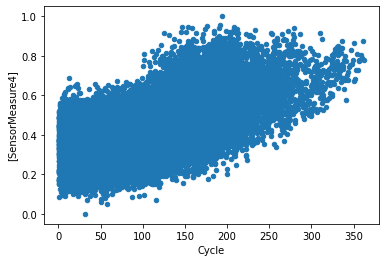

ORIGINAL


<Figure size 432x288 with 0 Axes>

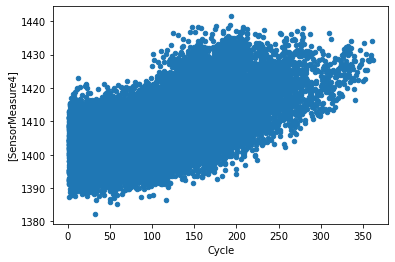

In [15]:
print("SCALED")
plt.figure()
scaled_df.plot.scatter(x="Cycle", y=["SensorMeasure4"])
plt.show()

print("ORIGINAL")
plt.figure()
data.plot.scatter(x="Cycle", y=["SensorMeasure4"])
plt.show()

/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/core.py:337: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig = self.plt.figure(figsize=self.figsize)


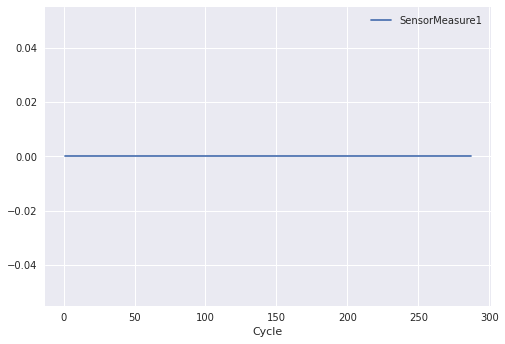

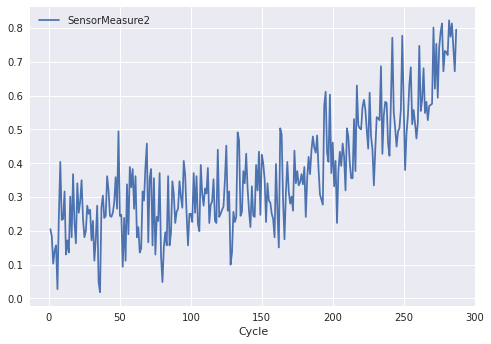

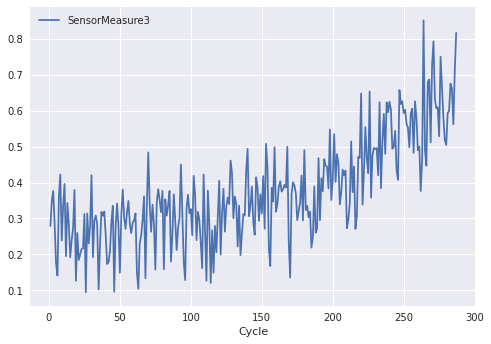

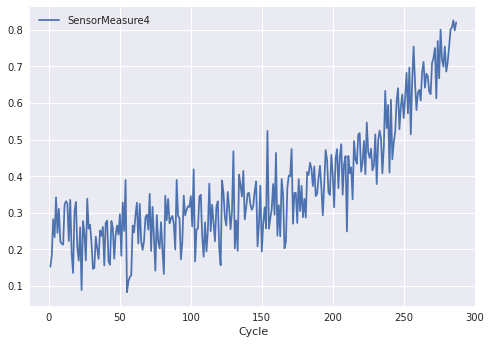

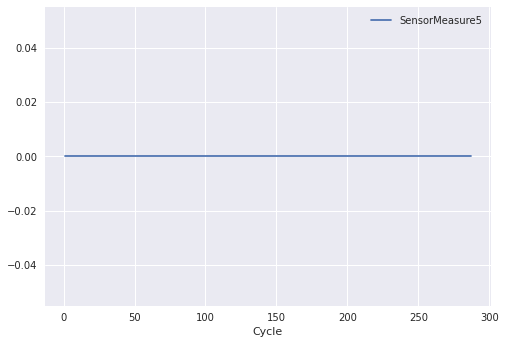

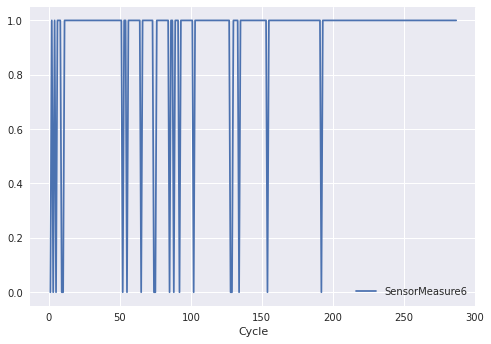

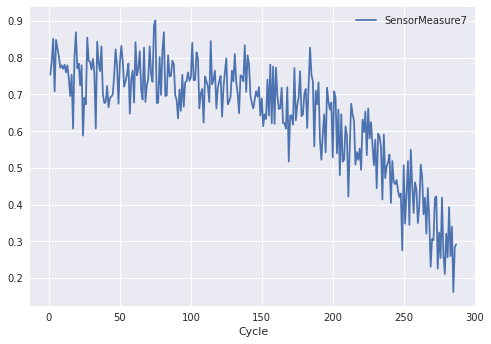

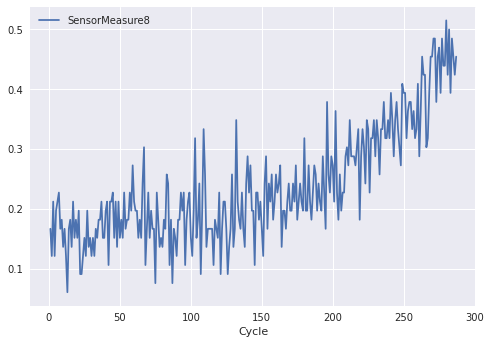

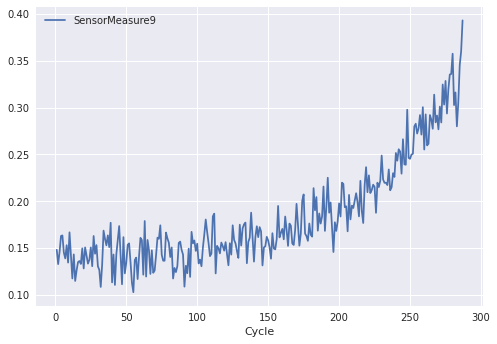

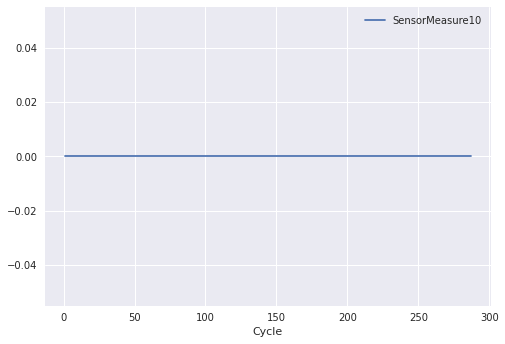

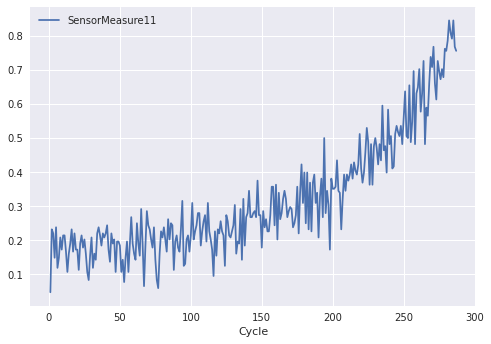

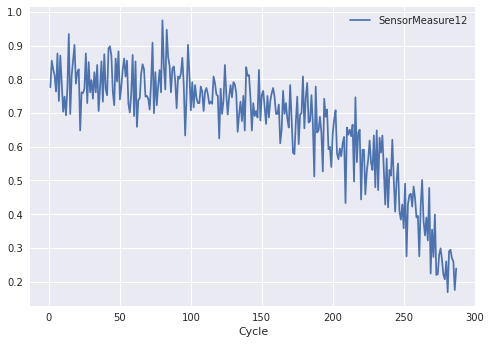

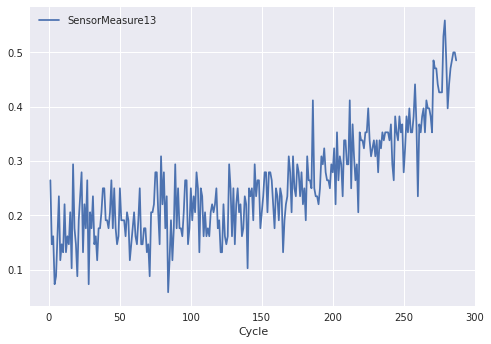

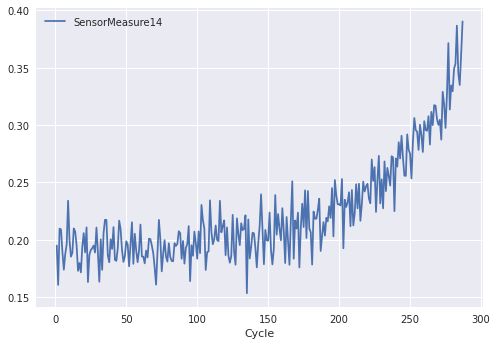

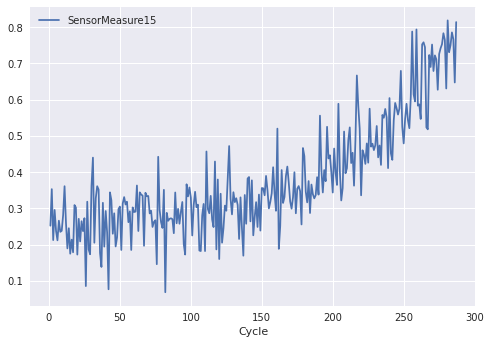

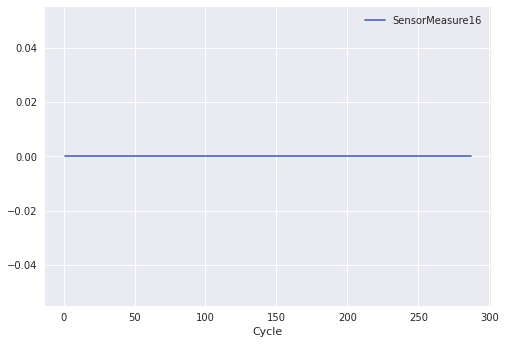

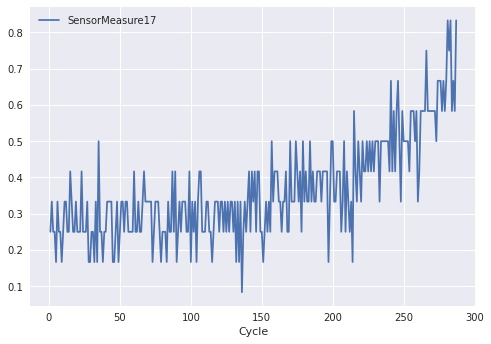

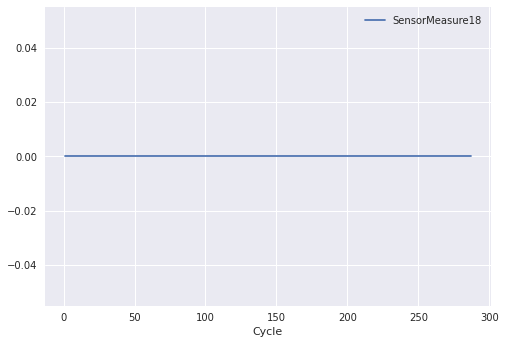

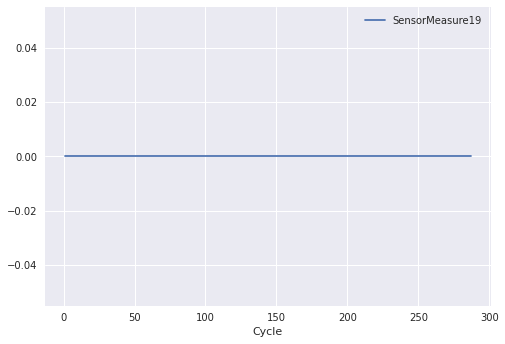

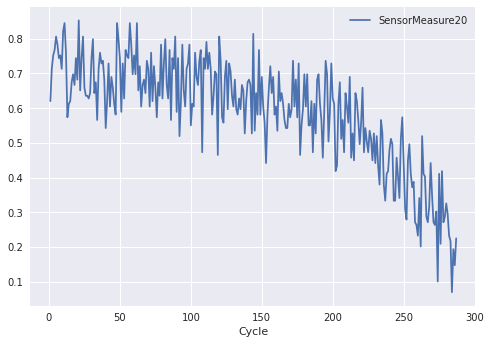

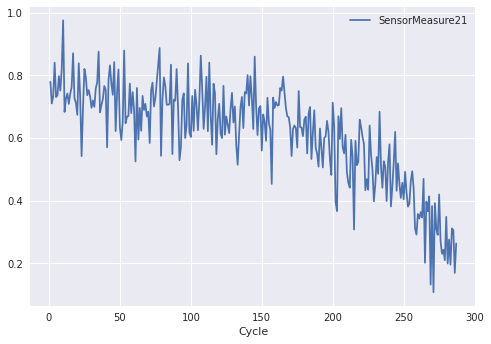

In [16]:
plt.style.use("seaborn")
sensor_count = 21
engine_id = 2
for i in range(1, sensor_count+1):
    y_value = "SensorMeasure" + str(i)
    scaled_df[scaled_df["ID"]==engine_id].plot(x="Cycle", y=y_value)

**SensorMeasure 1, 5, 6, 10, 16, 18, 19 Gereksiz gibi görünüyor.**

In [17]:
scaled_clean_df = scaled_df.drop(columns=["SensorMeasure1", "SensorMeasure5", "SensorMeasure6", "SensorMeasure10",
                                         "SensorMeasure16", "SensorMeasure18", "SensorMeasure19"])
scaled_clean_df

,ID,Cycle,RUL,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21
0,1,1,191,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662
1,1,2,190,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014
2,1,3,189,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375
3,1,4,188,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386
4,1,5,187,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,4,0.686747,0.587312,0.782917,0.254428,0.439394,0.196491,0.726190,0.170576,0.558824,0.194344,0.656791,0.750000,0.271318,0.109500
20627,100,197,3,0.701807,0.729453,0.866475,0.162641,0.500000,0.194651,0.708333,0.211087,0.500000,0.188668,0.727203,0.583333,0.124031,0.366197
20628,100,198,2,0.665663,0.684979,0.775321,0.175523,0.515152,0.198196,0.738095,0.281450,0.529412,0.212148,0.922278,0.833333,0.232558,0.053991
20629,100,199,1,0.608434,0.746021,0.747468,0.133655,0.530303,0.233285,0.916667,0.208955,0.514706,0.203065,0.823394,0.583333,0.116279,0.234466


In [18]:
cycle_counts = scaled_clean_df.groupby("ID")["Cycle"].max().reset_index()

<AxesSubplot:xlabel='Cycle', ylabel='[ID]'>

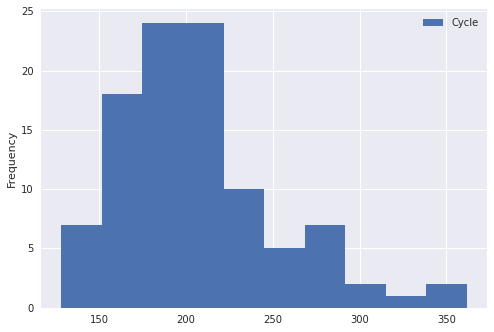

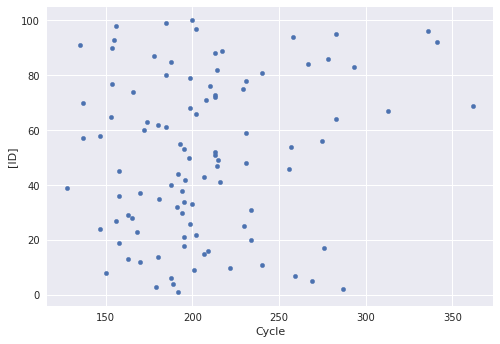

In [19]:
cycle_counts.plot(x="ID", y=["Cycle"], kind="hist")
cycle_counts.plot.scatter(x="Cycle", y=["ID"])

In [20]:
standart_deviations = scaled_clean_df.groupby("ID").std().reset_index().drop(columns=["Cycle"])
standart_deviations

,ID,RUL,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21
0,1,55.569776,0.146625,0.125567,0.144592,0.146605,0.107445,0.022040,0.159730,0.159739,0.113177,0.028708,0.131299,0.122972,0.129456,0.145127
1,2,82.993976,0.168739,0.143814,0.164369,0.151486,0.095456,0.056052,0.174805,0.170441,0.093913,0.044809,0.158244,0.137273,0.154521,0.158514
2,3,51.816986,0.142828,0.139224,0.145343,0.118194,0.060541,0.157932,0.144292,0.126820,0.060616,0.151923,0.140900,0.130898,0.128769,0.144621
3,4,54.703748,0.132966,0.133184,0.130612,0.114062,0.049289,0.164102,0.132574,0.113040,0.051204,0.158385,0.122919,0.133571,0.123490,0.129528
4,5,77.797815,0.166127,0.153927,0.165131,0.144241,0.084124,0.096042,0.170083,0.160618,0.083008,0.085046,0.148742,0.145005,0.145064,0.155627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,97.139076,0.150910,0.127605,0.148397,0.139220,0.092397,0.031384,0.155270,0.150801,0.089307,0.021570,0.138400,0.126088,0.139889,0.146912
96,97,58.456537,0.142748,0.134400,0.129455,0.108132,0.061978,0.181444,0.124187,0.113887,0.053248,0.174824,0.130981,0.130123,0.132528,0.128832
97,98,45.177428,0.158405,0.137612,0.164611,0.144709,0.118285,0.022617,0.176837,0.165183,0.109145,0.030238,0.137621,0.117308,0.137339,0.148369
98,99,53.549043,0.151268,0.124649,0.149093,0.142856,0.110141,0.017695,0.162936,0.162562,0.103868,0.021488,0.145633,0.123029,0.130080,0.146928


<AxesSubplot:>

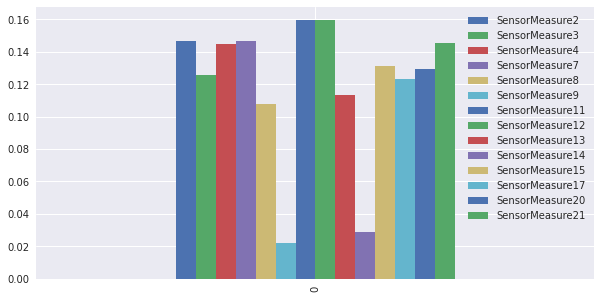

In [21]:
engine_id = 1
standart_deviations[standart_deviations["ID"]==engine_id].plot(y=["SensorMeasure2","SensorMeasure3","SensorMeasure4","SensorMeasure7",
                                                                 "SensorMeasure8","SensorMeasure9","SensorMeasure11","SensorMeasure12",
                                                                 "SensorMeasure13","SensorMeasure14","SensorMeasure15","SensorMeasure17",
                                                                 "SensorMeasure20","SensorMeasure21"], kind="bar", figsize=(10, 5))

<AxesSubplot:xlabel='SensorMeasure20', ylabel='[SensorMeasure21]'>

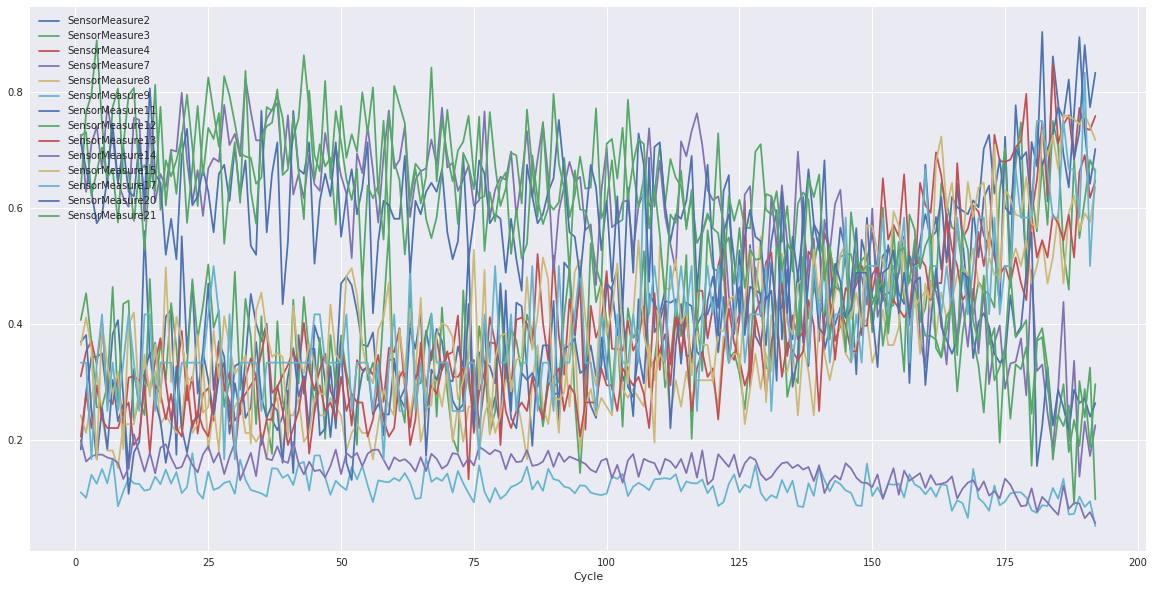

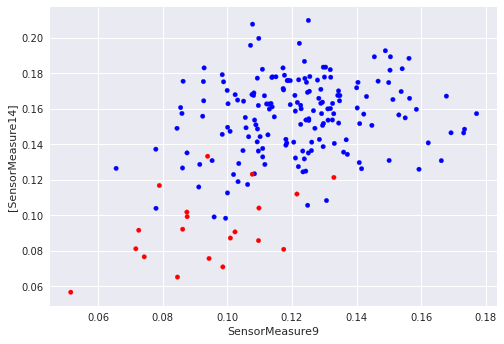

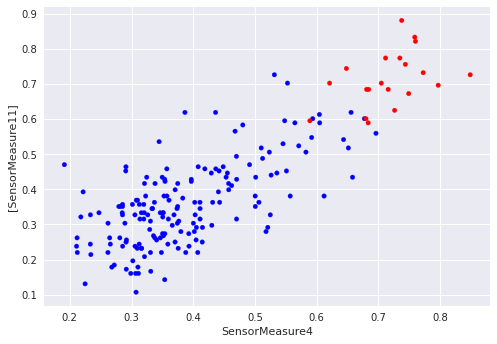

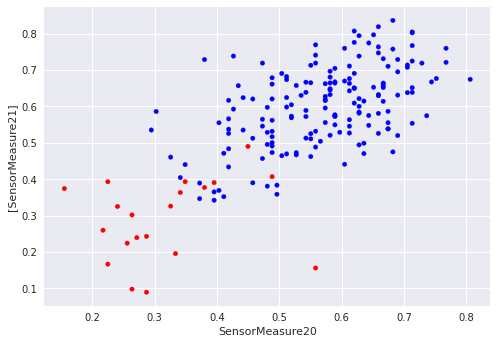

In [22]:
# Genel görüntü
sensors = ["SensorMeasure2","SensorMeasure3","SensorMeasure4","SensorMeasure7",
           "SensorMeasure8","SensorMeasure9","SensorMeasure11","SensorMeasure12",
           "SensorMeasure13","SensorMeasure14","SensorMeasure15","SensorMeasure17",
           "SensorMeasure20","SensorMeasure21"]

engine_to_check = 1

scaled_clean_df[scaled_clean_df["ID"]==engine_to_check].plot(x="Cycle", y=sensors, figsize=(20, 10))

rul_fixed_df = scaled_clean_df.copy()
rul_fixed_df.loc[rul_fixed_df["RUL"] < 20, "RUL"] = 0
rul_fixed_df.loc[rul_fixed_df["RUL"] >= 20, "RUL"] = 1
rul_fixed_df
col = rul_fixed_df[rul_fixed_df["ID"]==engine_to_check].RUL.map({1:'b', 0:'r'})
rul_fixed_df[rul_fixed_df["ID"]==engine_to_check].plot.scatter(x=sensors[5], y=[sensors[9]], c=col)
rul_fixed_df[rul_fixed_df["ID"]==engine_to_check].plot.scatter(x=sensors[2], y=[sensors[6]], c=col)
rul_fixed_df[rul_fixed_df["ID"]==engine_to_check].plot.scatter(x=sensors[12], y=[sensors[13]], c=col)

In [23]:
import seaborn

In [24]:
correlation_df = scaled_clean_df.drop(columns=["ID", "Cycle", "RUL"])
corr_default = correlation_df.corr()
corr_default

,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21
SensorMeasure2,1.000000,0.602610,0.714949,-0.702136,0.662325,0.273764,0.740020,-0.724578,0.661792,0.179752,0.675975,0.629886,-0.661841,-0.668050
SensorMeasure3,0.602610,1.000000,0.678413,-0.664595,0.602481,0.322964,0.695900,-0.680307,0.600963,0.237137,0.639921,0.600017,-0.625941,-0.633901
SensorMeasure4,0.714949,0.678413,1.000000,-0.793130,0.746852,0.297429,0.830136,-0.815591,0.745158,0.190748,0.758459,0.703499,-0.748067,-0.745193
SensorMeasure7,-0.702136,-0.664595,-0.793130,1.000000,-0.767132,-0.217835,-0.822805,0.812713,-0.764611,-0.110053,-0.747051,-0.692893,0.736163,0.737447
SensorMeasure8,0.662325,0.602481,0.746852,-0.767132,1.000000,-0.032091,0.782213,-0.786540,0.826084,-0.144787,0.700949,0.627785,-0.687030,-0.688840
SensorMeasure9,0.273764,0.322964,0.297429,-0.217835,-0.032091,1.000000,0.274591,-0.210238,-0.034763,0.963157,0.293753,0.337110,-0.285280,-0.292795
SensorMeasure11,0.740020,0.695900,0.830136,-0.822805,0.782213,0.274591,1.000000,-0.846884,0.780761,0.163408,0.780913,0.722296,-0.771510,-0.772554
SensorMeasure12,-0.724578,-0.680307,-0.815591,0.812713,-0.786540,-0.210238,-0.846884,1.000000,-0.788441,-0.098141,-0.766052,-0.703485,0.751943,0.756263
SensorMeasure13,0.661792,0.600963,0.745158,-0.764611,0.826084,-0.034763,0.780761,-0.788441,1.000000,-0.147036,0.697662,0.627410,-0.686172,-0.688948
SensorMeasure14,0.179752,0.237137,0.190748,-0.110053,-0.144787,0.963157,0.163408,-0.098141,-0.147036,1.000000,0.193761,0.246621,-0.187364,-0.192415


<AxesSubplot:>

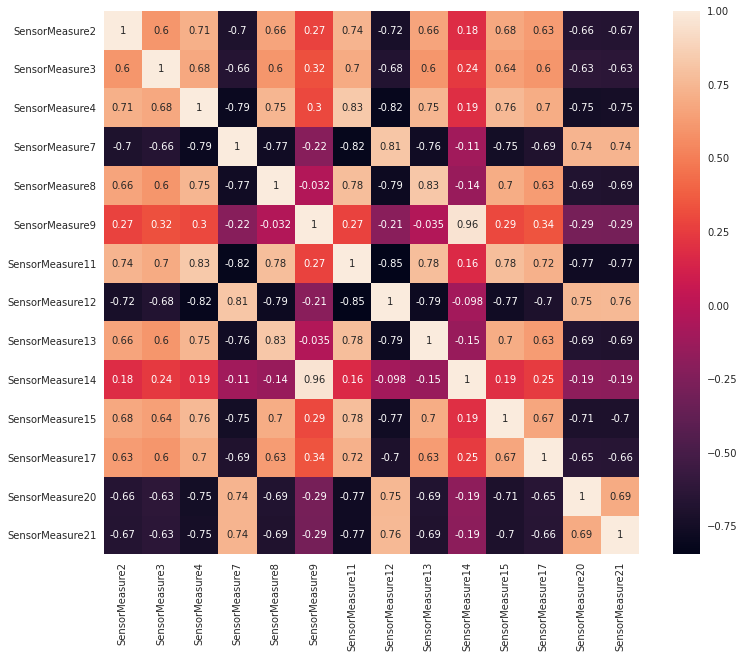

In [25]:
plt.figure(figsize=(12, 10))
seaborn.heatmap(corr_default, annot=True, cmap="rocket")

In [26]:
correlation_df = scaled_df.drop(columns=["ID", "Cycle", "RUL"])
corr_default = correlation_df.corr()
corr_default

,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,SensorMeasure6,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure10,...,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21
SensorMeasure1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SensorMeasure2,NaN,1.000000,0.602610,0.714949,NaN,0.132242,-0.702136,0.662325,0.273764,NaN,...,-0.724578,0.661792,0.179752,0.675975,NaN,0.629886,NaN,NaN,-0.661841,-0.668050
SensorMeasure3,NaN,0.602610,1.000000,0.678413,NaN,0.116039,-0.664595,0.602481,0.322964,NaN,...,-0.680307,0.600963,0.237137,0.639921,NaN,0.600017,NaN,NaN,-0.625941,-0.633901
SensorMeasure4,NaN,0.714949,0.678413,1.000000,NaN,0.150480,-0.793130,0.746852,0.297429,NaN,...,-0.815591,0.745158,0.190748,0.758459,NaN,0.703499,NaN,NaN,-0.748067,-0.745193
SensorMeasure5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SensorMeasure6,NaN,0.132242,0.116039,0.150480,NaN,1.000000,-0.155720,0.152161,0.019347,NaN,...,-0.155884,0.158276,-0.002112,0.149042,NaN,0.130810,NaN,NaN,-0.141419,-0.137419
SensorMeasure7,NaN,-0.702136,-0.664595,-0.793130,NaN,-0.155720,1.000000,-0.767132,-0.217835,NaN,...,0.812713,-0.764611,-0.110053,-0.747051,NaN,-0.692893,NaN,NaN,0.736163,0.737447
SensorMeasure8,NaN,0.662325,0.602481,0.746852,NaN,0.152161,-0.767132,1.000000,-0.032091,NaN,...,-0.786540,0.826084,-0.144787,0.700949,NaN,0.627785,NaN,NaN,-0.687030,-0.688840
SensorMeasure9,NaN,0.273764,0.322964,0.297429,NaN,0.019347,-0.217835,-0.032091,1.000000,NaN,...,-0.210238,-0.034763,0.963157,0.293753,NaN,0.337110,NaN,NaN,-0.285280,-0.292795
SensorMeasure10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<AxesSubplot:>

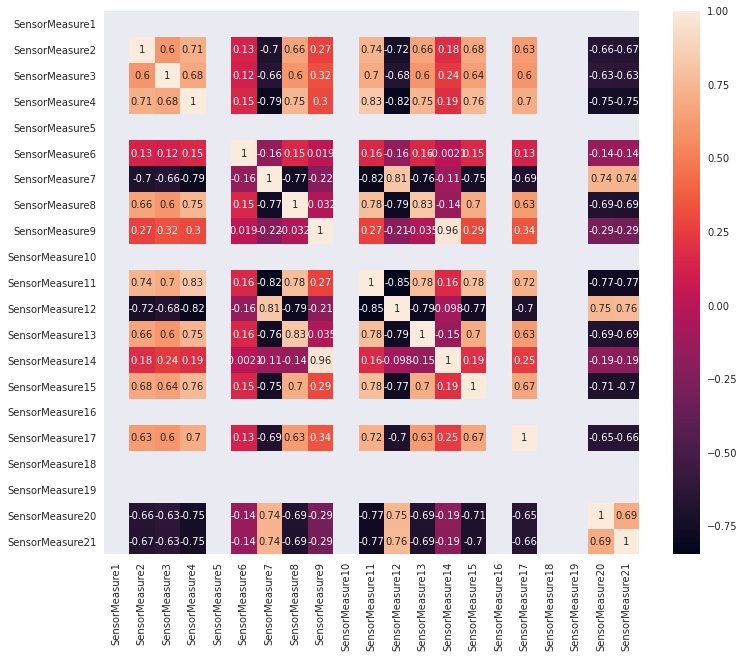

In [27]:
plt.figure(figsize=(12, 10))
seaborn.heatmap(corr_default, annot=True, cmap="rocket")

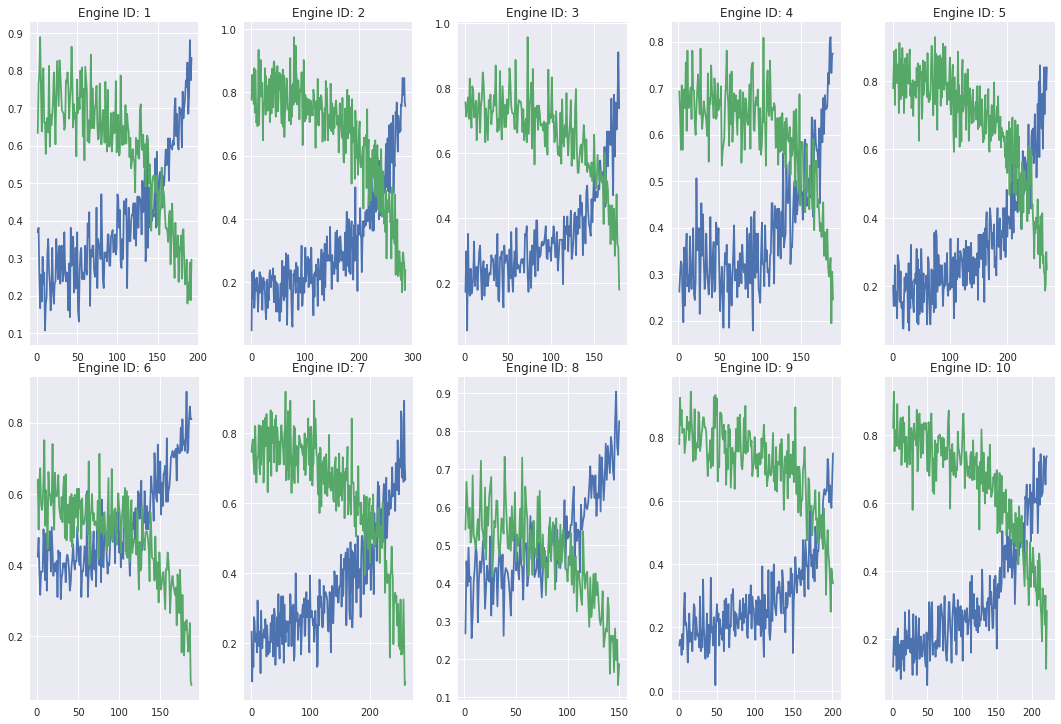

In [28]:
S1, S2 = "SensorMeasure11", "SensorMeasure12"
fig, axes = plt.subplots(2, 5, figsize=(15, 10))
fig.tight_layout()

for i in range(2):
    for j in range(5):
        df_used = scaled_clean_df[scaled_clean_df["ID"]==(5*i+j+1)]
        axes[i][j].plot(df_used["Cycle"], df_used[S1])
        axes[i][j].plot(df_used["Cycle"], df_used[S2])
        axes[i][j].title.set_text("Engine ID: " + str(5*i+j+1))

plt.show()

<AxesSubplot:title={'center':'Motor ID: 1'}>

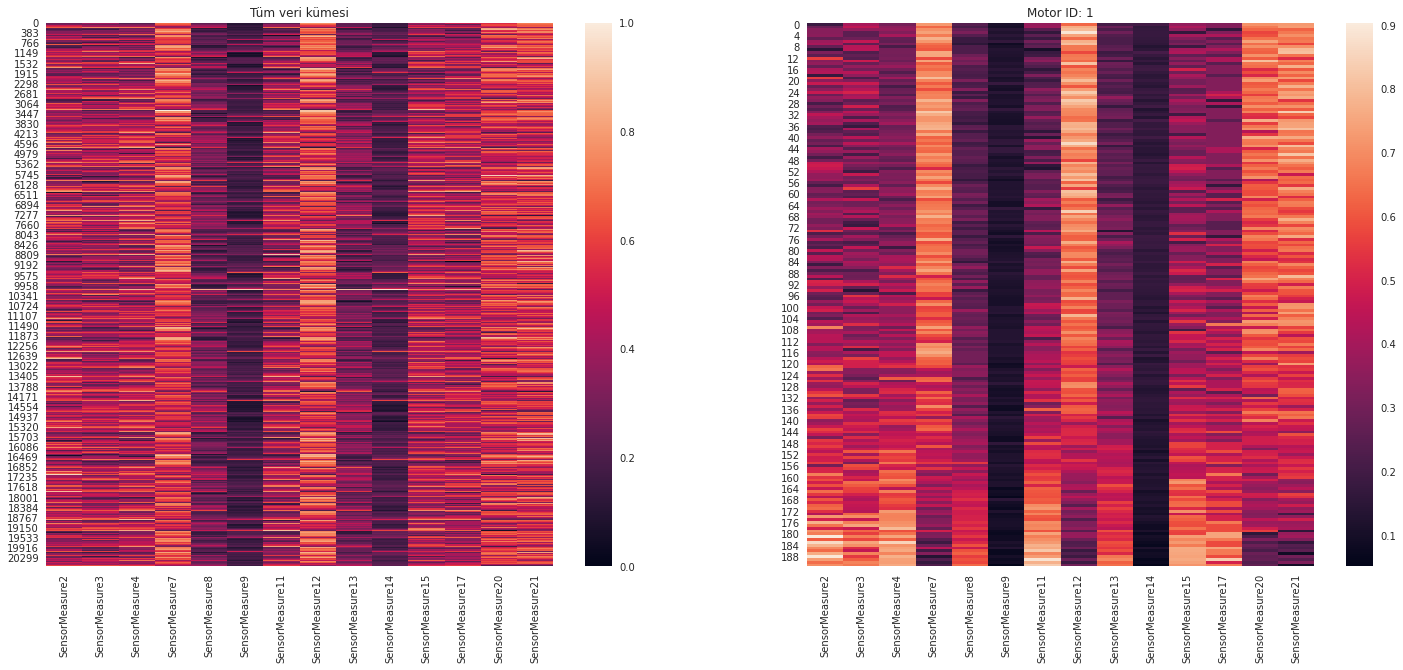

In [29]:
# Veri kümesi boyunca sensörlerin değerleri

fig, axes = plt.subplots(1, 2, figsize=(25, 10))
axes[0].title.set_text("Tüm veri kümesi")
seaborn.heatmap(scaled_clean_df.copy().drop(columns=["ID", "Cycle", "RUL"]), ax=axes[0])

engine_id = 1
axes[1].title.set_text("Motor ID: " + str(engine_id))
seaborn.heatmap(scaled_clean_df[scaled_clean_df["ID"]==engine_id].copy().drop(columns=["ID", "Cycle", "RUL"]), ax=axes[1])

<AxesSubplot:title={'center':'Çıkarılan özelliklerle Motor ID: 1'}>

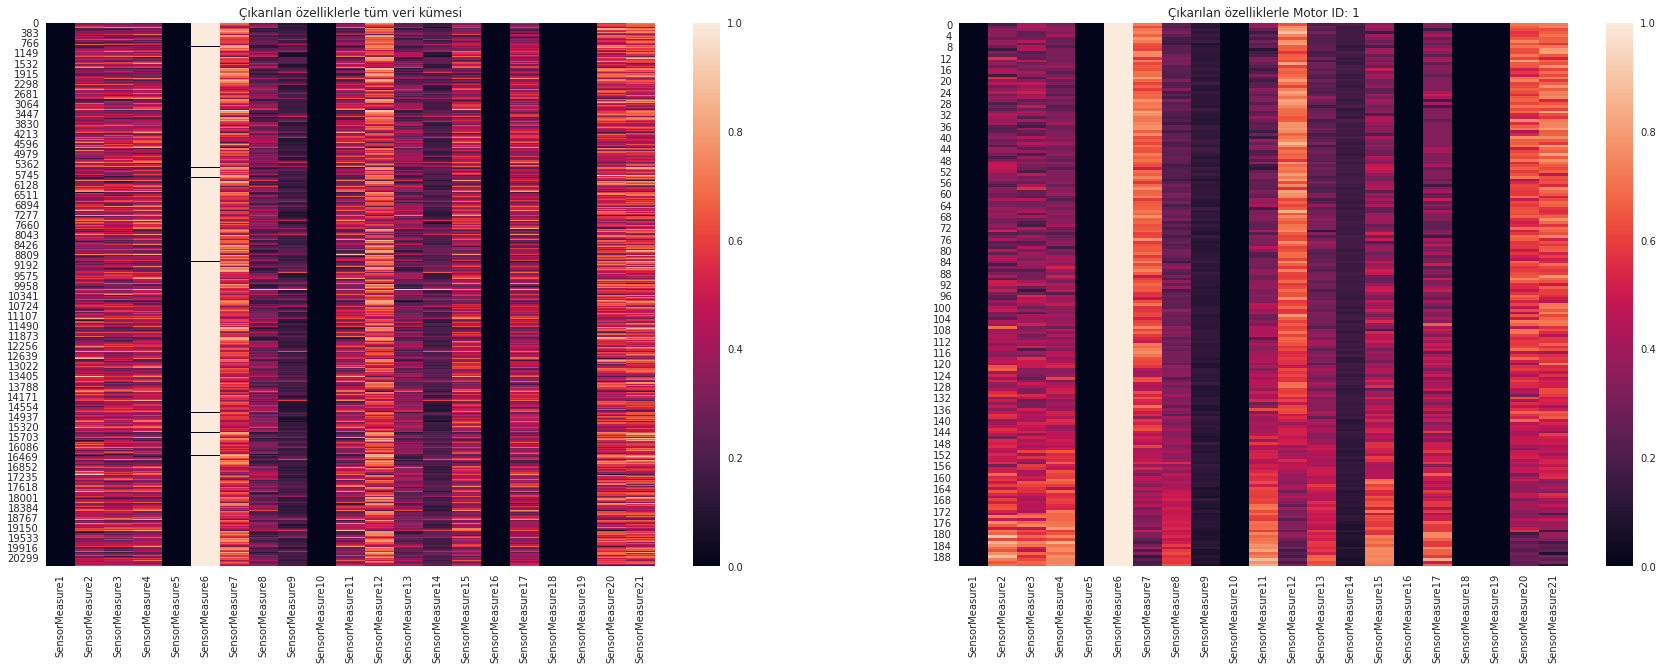

In [30]:
# Veri kümesinden çıkardığım sensörleri geri ekleyince oluşan heatmap

fig, axes = plt.subplots(1, 2, figsize=(30, 10))
axes[0].title.set_text("Çıkarılan özelliklerle tüm veri kümesi")
seaborn.heatmap(scaled_df.copy().drop(columns=["ID", "Cycle", "RUL"]), ax=axes[0])

engine_id = 1
axes[1].title.set_text("Çıkarılan özelliklerle Motor ID: " + str(engine_id))
seaborn.heatmap(scaled_df[scaled_df["ID"]==engine_id].copy().drop(columns=["ID", "Cycle", "RUL"]), ax=axes[1])

# **VERILERI SINIFLANDIRMA**

In [31]:
class_df = scaled_clean_df.copy()
class_df['HS'] = [0 for x in range(len(class_df['RUL']))]
class_df.loc[class_df["RUL"] <= 10, "HS"] = 'Not Okay'
class_df.loc[class_df['RUL'] >= 120, 'HS'] = 'Okay'
class_df.loc[(class_df['RUL'] < 120) & (class_df['RUL'] > 10), 'HS'] = 'Degradation'
class_df

,ID,Cycle,RUL,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21,HS
0,1,1,191,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,Okay
1,1,2,190,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,Okay
2,1,3,189,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,Okay
3,1,4,188,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,Okay
4,1,5,187,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,Okay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,4,0.686747,0.587312,0.782917,0.254428,0.439394,0.196491,0.726190,0.170576,0.558824,0.194344,0.656791,0.750000,0.271318,0.109500,Not Okay
20627,100,197,3,0.701807,0.729453,0.866475,0.162641,0.500000,0.194651,0.708333,0.211087,0.500000,0.188668,0.727203,0.583333,0.124031,0.366197,Not Okay
20628,100,198,2,0.665663,0.684979,0.775321,0.175523,0.515152,0.198196,0.738095,0.281450,0.529412,0.212148,0.922278,0.833333,0.232558,0.053991,Not Okay
20629,100,199,1,0.608434,0.746021,0.747468,0.133655,0.530303,0.233285,0.916667,0.208955,0.514706,0.203065,0.823394,0.583333,0.116279,0.234466,Not Okay


<AxesSubplot:xlabel='Cycle', ylabel='[HS Numeric]'>

<Figure size 576x396 with 0 Axes>

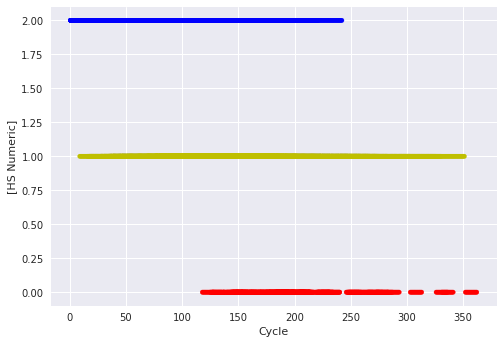

In [32]:
HS_numeric = class_df.HS.map({'Okay':2, 'Not Okay':0, 'Degradation':1})
col = class_df.HS.map({'Okay':'b', 'Not Okay':'r', 'Degradation':'y'})
class_df['HS Numeric'] = HS_numeric
plt.figure()
class_df.plot.scatter(x="Cycle", y=["HS Numeric"], color=col)

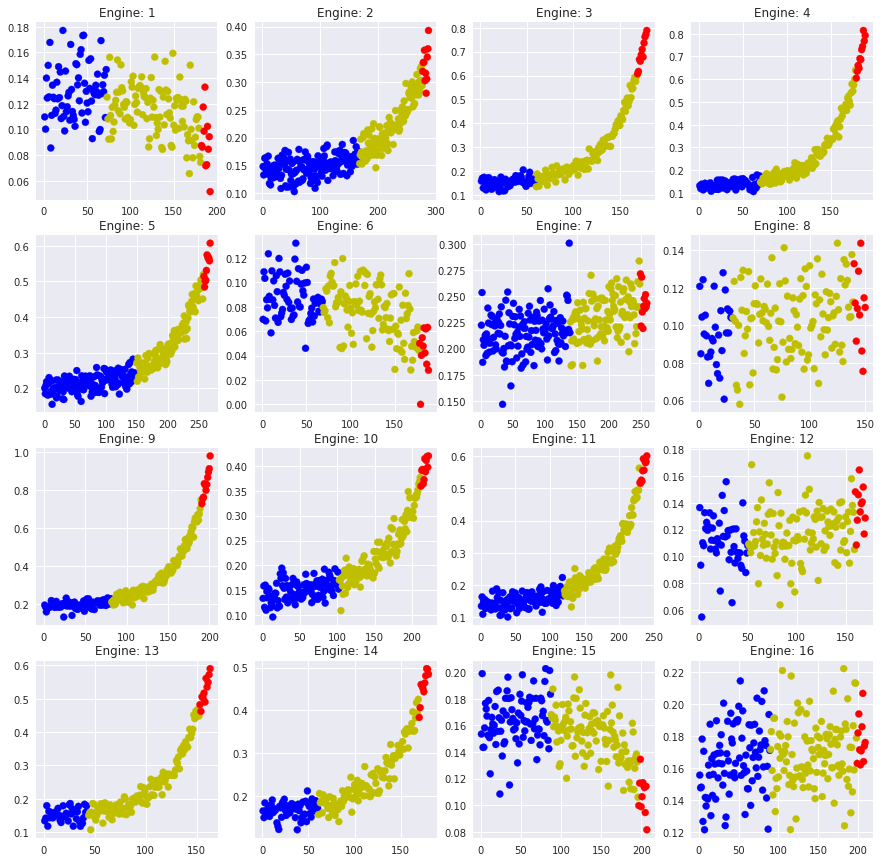

<Figure size 576x396 with 0 Axes>

<Figure size 576x396 with 0 Axes>

<Figure size 576x396 with 0 Axes>

<Figure size 576x396 with 0 Axes>

<Figure size 576x396 with 0 Axes>

...

<Figure size 576x396 with 0 Axes>

<Figure size 576x396 with 0 Axes>

<Figure size 576x396 with 0 Axes>

<Figure size 576x396 with 0 Axes>

<Figure size 576x396 with 0 Axes>

In [33]:
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
engine = 1
sensor = "SensorMeasure9"
for i in range(4):
    for j in range(4):
        col = class_df[class_df['ID']==engine].HS.map({'Okay':'b', 'Not Okay':'r', 'Degradation':'y'})
        plt.figure()
        axes[i][j].scatter(class_df[class_df["ID"]==engine]["Cycle"], class_df[class_df["ID"]==engine][sensor], color=col)
        axes[i][j].title.set_text("Engine: " + str(engine))
        engine += 1


In [34]:
#dataset özeti
class_df.info

<bound method DataFrame.info of         ID  Cycle  RUL  SensorMeasure2  SensorMeasure3  SensorMeasure4  \
0        1      1  191        0.183735        0.406802        0.309757   
1        1      2  190        0.283133        0.453019        0.352633   
2        1      3  189        0.343373        0.369523        0.370527   
3        1      4  188        0.343373        0.256159        0.331195   
4        1      5  187        0.349398        0.257467        0.404625   
...    ...    ...  ...             ...             ...             ...   
20626  100    196    4        0.686747        0.587312        0.782917   
20627  100    197    3        0.701807        0.729453        0.866475   
20628  100    198    2        0.665663        0.684979        0.775321   
20629  100    199    1        0.608434        0.746021        0.747468   
20630  100    200    0        0.795181        0.639634        0.842167   

       SensorMeasure7  SensorMeasure8  SensorMeasure9  SensorMeasure11  \
0    

In [35]:
#kaç tane (target) okey not okey ve degradation var?
class_df['HS Numeric'].value_counts()

1    10900
2     8631
0     1100
Name: HS Numeric, dtype: int64

In [36]:
#feature vectörünü ve hedef değişkenini bildirelim
X = class_df.drop([ 'ID','Cycle','RUL','HS','HS Numeric'], axis=1)

y = class_df['HS Numeric']

In [37]:
#X ve y'yi eğitim ve test setlerine ayırın
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [38]:
#X_train ve x_test in shapeini kontrol edelim
X_train.shape, X_test.shape

((13822, 14), (6809, 14))

In [39]:
#X_traindeki dataların typelarına bakalım
X_train.dtypes

SensorMeasure2     float64
SensorMeasure3     float64
SensorMeasure4     float64
SensorMeasure7     float64
SensorMeasure8     float64
SensorMeasure9     float64
SensorMeasure11    float64
SensorMeasure12    float64
SensorMeasure13    float64
SensorMeasure14    float64
SensorMeasure15    float64
SensorMeasure17    float64
SensorMeasure20    float64
SensorMeasure21    float64
dtype: object

In [40]:
#all of the values are number
X_train.head()

,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21
20118,0.355422,0.411380,0.222991,0.666667,0.136364,0.212959,0.232143,0.927505,0.176471,0.266849,0.267795,0.416667,0.666667,0.619856
1225,0.421687,0.367779,0.463876,0.570048,0.409091,0.084537,0.440476,0.420043,0.441176,0.094437,0.319738,0.500000,0.550388,0.470036
6408,0.593373,0.712448,0.861918,0.228663,0.484848,0.288028,0.744048,0.219616,0.485294,0.293890,0.779915,0.666667,0.341085,0.244270
16870,0.530120,0.735993,0.705604,0.322061,0.515152,0.114018,0.803571,0.243070,0.544118,0.134844,0.729511,0.666667,0.310078,0.261944
13583,0.707831,0.560715,0.551992,0.558776,0.242424,0.310195,0.500000,0.488273,0.352941,0.344102,0.534436,0.500000,0.395349,0.447390


In [41]:
# Kategori kodlayıcılarını import edelim (encoders)
import category_encoders as ce

In [42]:
# değişkenleri sıralı kodlamayla kodlayalım
#encoder = ce.OrdinalEncoder(cols=['HS'])

#X_train = encoder.fit_transform(X_train)

#X_test = encoder.transform(X_test)

In [43]:
X_train.head()

,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21
20118,0.355422,0.411380,0.222991,0.666667,0.136364,0.212959,0.232143,0.927505,0.176471,0.266849,0.267795,0.416667,0.666667,0.619856
1225,0.421687,0.367779,0.463876,0.570048,0.409091,0.084537,0.440476,0.420043,0.441176,0.094437,0.319738,0.500000,0.550388,0.470036
6408,0.593373,0.712448,0.861918,0.228663,0.484848,0.288028,0.744048,0.219616,0.485294,0.293890,0.779915,0.666667,0.341085,0.244270
16870,0.530120,0.735993,0.705604,0.322061,0.515152,0.114018,0.803571,0.243070,0.544118,0.134844,0.729511,0.666667,0.310078,0.261944
13583,0.707831,0.560715,0.551992,0.558776,0.242424,0.310195,0.500000,0.488273,0.352941,0.344102,0.534436,0.500000,0.395349,0.447390


In [44]:
X_test.head()

,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21
13857,0.319277,0.305210,0.441087,0.516908,0.257576,0.181728,0.428571,0.565032,0.352941,0.212354,0.375529,0.333333,0.705426,0.512704
1710,0.668675,0.753216,0.659183,0.302738,0.621212,0.075563,0.761905,0.251599,0.602941,0.135515,0.640631,0.583333,0.348837,0.233223
9278,0.322289,0.355788,0.212188,0.703704,0.181818,0.213138,0.095238,0.739872,0.220588,0.224946,0.309735,0.166667,0.635659,0.678956
10786,0.780120,0.670373,0.861074,0.244767,0.393939,0.601813,0.773810,0.187633,0.397059,0.620755,0.787226,0.583333,0.124031,0.215134
19709,0.415663,0.560933,0.338454,0.684380,0.333333,0.169299,0.279762,0.620469,0.367647,0.216844,0.320508,0.333333,0.542636,0.593068


In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

In [46]:
# kriter gini indeksi ile DecisionTreeClassifier modelini somutlaştıralım
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=0)


# fit the model
clf_gini.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=0)

In [47]:
#Kriter gini indeksi ile Test seti sonuçlarını tahmin edelim
y_pred_gini = clf_gini.predict(X_test)

In [48]:
#Kriter gini indeksi ile accuracy score kontrol edin
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.7465


In [49]:
accuracy_score(y_test, y_pred_gini)

0.7465119694521957

In [50]:
#Train ve test setlerin accuracy lerini karşılaştıralım

y_pred_train_gini = clf_gini.predict(X_train)

y_pred_train_gini

array([2, 1, 0, ..., 1, 2, 2], dtype=int64)

In [51]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_gini)))

Training-set accuracy score: 0.8455


In [52]:
#overfitting ve underfitting için bakıyoruz
#training ve test setin score larını print edelim

print('Training set score: {:.4f}'.format(clf_gini.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(clf_gini.score(X_test, y_test)))

#ikiside aynı overfitting olabilir mi aşırı mı uyumlu sor?

Training set score: 0.8455
Test set score: 0.7465


In [53]:
#karar ağacını çizelim

#plt.figure(figsize=(12,8))

from sklearn import tree

#tree.plot_tree(clf_gini.fit(X_train, y_train))

In [54]:
# Karar ağacı Classifier (Criterion Entropy)
# DecisionTreeClassifier modelini ölçüt entropisi ile somutlaştır
clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=0)


# fit the model
clf_en.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=0)

In [55]:
#test set sonuçlarını criterion entropy ile tahmin edelim
y_pred_en = clf_en.predict(X_test)

In [56]:
#Criterion Entrop ile accuracy score u kontrol edelim
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with criterion entropy: 0.7543


In [57]:
#Train ve Test setteki accuracy leri karşılaştıralım
y_pred_train_en = clf_en.predict(X_train)

y_pred_train_en

array([2, 1, 0, ..., 1, 2, 2], dtype=int64)

In [58]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 0.8272


In [59]:
#overfitting ve underfitting kontrol edelim (train ve test sette)
print('Training set score: {:.4f}'.format(clf_en.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(clf_en.score(X_test, y_test)))

Training set score: 0.8272
Test set score: 0.7543


In [60]:
#plt.figure(figsize=(12,8))

#from sklearn import tree

#tree.plot_tree(clf_en.fit(X_train, y_train))

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import GridSearchCV

# Choose the type of classifier. 
clf = RandomForestClassifier(random_state=42)

# Choose some parameter combinations to try
parameters = {'n_estimators': [10,20,50], 
              'max_features': ['log2', 'sqrt','auto'], 
              'criterion': ['entropy', 'gini'],
              'max_depth': [4, 5, 6, 10], 
              
             }

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(accuracy_score)

grid_obj = GridSearchCV(estimator= clf, param_grid=parameters, cv= 5)
grid_obj.fit(X_train, y_train)
# Run the grid search
#grid_obj = GridSearchCV(clf, parameters, scoring=acc_scorer)
#grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
clf = grid_obj.best_estimator_

# Fit the best algorithm to the data. 
clf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=10, max_features='log2',
                       n_estimators=50, random_state=42)

In [62]:
#predictions = clf.predict(X_test)
#print(accuracy_score(y_test, predictions))


In [63]:
grid_obj.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'log2',
 'n_estimators': 50}

In [64]:
rfc1=RandomForestClassifier(random_state=42, max_features='log2', n_estimators= 20, max_depth=8, criterion='gini')

In [65]:
rfc1.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, max_features='log2', n_estimators=20,
                       random_state=42)

In [66]:
pred=rfc1.predict(X_train)
print("Accuracy for Random Forest on data: ",accuracy_score(y_train,pred))

Accuracy for Random Forest on data:  0.8236145275647518
